In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
cities = {
    "Delhi": {
        "state": "Delhi",
        "latitude": 28.6139,
        "longitude": 77.2090
    },
    
    "Mumbai": {
        "state": "Maharashtra",
        "latitude": 19.0760,
        "longitude": 72.8777
    },
    
    "Bengaluru": {
        "state": "Karnataka",
        "latitude": 12.9716,
        "longitude": 77.5946
    },
    
    "Chennai": {
        "state": "Tamil Nadu",
        "latitude": 13.0827,
        "longitude": 80.2707
    },
    
    "Bhopal": {
        "state": "Madhya Pradesh",
        "latitude": 23.2599,
        "longitude": 77.4126
    }
}

print("Number of cities:", len(cities))

for city, details in cities.items():
    print(
        city,
        "→",
        details["state"],
        "| Latitude:", details["latitude"],
        "| Longitude:", details["longitude"]
    )

Number of cities: 5
Delhi → Delhi | Latitude: 28.6139 | Longitude: 77.209
Mumbai → Maharashtra | Latitude: 19.076 | Longitude: 72.8777
Bengaluru → Karnataka | Latitude: 12.9716 | Longitude: 77.5946
Chennai → Tamil Nadu | Latitude: 13.0827 | Longitude: 80.2707
Bhopal → Madhya Pradesh | Latitude: 23.2599 | Longitude: 77.4126


In [6]:
import requests

# Bhopal coordinates
latitude = cities["Bhopal"]["latitude"]
longitude = cities["Bhopal"]["longitude"]

url = "https://historical-forecast-api.open-meteo.com/v1/forecast"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": "2022-01-01",
    "end_date": "2022-01-07",
    
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "dew_point_2m",
        "apparent_temperature",
        "precipitation_probability",
        "precipitation",
        "rain",
        "surface_pressure",
        "cloud_cover",
        "wind_speed_10m",
        "wind_direction_10m",
        "wind_gusts_10m"
    ],
    
    "timezone": "auto"
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)

Status code: 200


In [8]:
data = response.json()

print(data.keys())

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])


In [10]:
print(data["hourly"].keys())

dict_keys(['time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation_probability', 'precipitation', 'rain', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m'])


In [12]:
hourly_data = data["hourly"]

df = pd.DataFrame(hourly_data)

df.head()

,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation_probability,precipitation,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m
0,2022-01-01T00:00,12.4,88,10.4,11.4,None,0.0,0.0,963.5,78,7.6,59,12.2
1,2022-01-01T01:00,12.1,90,10.4,11.2,None,0.0,0.0,963.1,45,6.9,47,12.6
2,2022-01-01T02:00,11.6,92,10.4,10.8,None,0.0,0.0,962.4,91,6.2,54,11.2
3,2022-01-01T03:00,11.4,92,10.2,10.5,None,0.0,0.0,961.9,100,6.6,68,11.2
4,2022-01-01T04:00,11.5,90,9.9,10.6,None,0.0,0.0,961.9,19,6.0,73,10.8


In [14]:
df["city"] = "Bhopal"
df["state"] = "Madhya Pradesh"

df.head()

,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation_probability,precipitation,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m,city,state
0,2022-01-01T00:00,12.4,88,10.4,11.4,None,0.0,0.0,963.5,78,7.6,59,12.2,Bhopal,Madhya Pradesh
1,2022-01-01T01:00,12.1,90,10.4,11.2,None,0.0,0.0,963.1,45,6.9,47,12.6,Bhopal,Madhya Pradesh
2,2022-01-01T02:00,11.6,92,10.4,10.8,None,0.0,0.0,962.4,91,6.2,54,11.2,Bhopal,Madhya Pradesh
3,2022-01-01T03:00,11.4,92,10.2,10.5,None,0.0,0.0,961.9,100,6.6,68,11.2,Bhopal,Madhya Pradesh
4,2022-01-01T04:00,11.5,90,9.9,10.6,None,0.0,0.0,961.9,19,6.0,73,10.8,Bhopal,Madhya Pradesh


In [16]:
df["time"] = pd.to_datetime(df["time"])

print(df["time"].dtype)

datetime64[ns]


In [18]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 168
Columns: 15


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   time                       168 non-null    datetime64[ns]
 1   temperature_2m             168 non-null    float64       
 2   relative_humidity_2m       168 non-null    int64         
 3   dew_point_2m               168 non-null    float64       
 4   apparent_temperature       168 non-null    float64       
 5   precipitation_probability  0 non-null      object        
 6   precipitation              168 non-null    float64       
 7   rain                       168 non-null    float64       
 8   surface_pressure           168 non-null    float64       
 9   cloud_cover                168 non-null    int64         
 10  wind_speed_10m             168 non-null    float64       
 11  wind_direction_10m         168 non-null    int64         
 12  wind_gus

In [22]:
df.describe()

,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m
count,168,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000
mean,2022-01-04 11:30:00,17.653571,75.095238,12.712500,17.434524,0.238095,0.238095,960.099405,43.035714,7.657143,100.196429,16.180357
min,2022-01-01 00:00:00,11.300000,40.000000,8.700000,10.400000,0.000000,0.000000,956.000000,0.000000,1.100000,2.000000,5.800000
25%,2022-01-02 17:45:00,14.275000,61.000000,11.100000,13.675000,0.000000,0.000000,958.600000,1.000000,6.075000,56.750000,11.200000
50%,2022-01-04 11:30:00,16.850000,78.000000,12.550000,17.150000,0.000000,0.000000,960.050000,40.000000,7.300000,78.000000,14.200000
75%,2022-01-06 05:15:00,21.125000,91.000000,14.225000,21.225000,0.000000,0.000000,961.525000,85.000000,8.700000,115.000000,19.500000
max,2022-01-07 23:00:00,26.000000,97.000000,16.700000,25.600000,10.000000,10.000000,965.800000,100.000000,17.400000,355.000000,36.000000
std,NaN,4.204501,16.717891,1.924789,4.505937,1.137642,1.137642,2.100057,39.082883,2.859454,72.020228,6.769527


In [24]:
import time

BASE_URL = "https://historical-forecast-api.open-meteo.com/v1/forecast"

weather_variables = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "apparent_temperature",
    "precipitation_probability",
    "precipitation",
    "rain",
    "surface_pressure",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "wind_gusts_10m"
]


def fetch_weather_data(city, details, start_date, end_date):

    params = {
        "latitude": details["latitude"],
        "longitude": details["longitude"],
        "start_date": start_date,
        "end_date": end_date,
        "hourly": weather_variables,
        "timezone": "auto"
    }

    response = requests.get(
        BASE_URL,
        params=params,
        timeout=60
    )

    response.raise_for_status()

    data = response.json()

    hourly_data = data["hourly"]

    city_df = pd.DataFrame(hourly_data)

    # Add location information
    city_df["city"] = city
    city_df["state"] = details["state"]
    city_df["latitude"] = details["latitude"]
    city_df["longitude"] = details["longitude"]

    return city_df

In [26]:
test_df = fetch_weather_data(
    "Bhopal",
    cities["Bhopal"],
    "2022-01-01",
    "2022-01-07"
)

print("Rows:", len(test_df))
print("Columns:", len(test_df.columns))

test_df.head()

Rows: 168
Columns: 17


,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation_probability,precipitation,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m,city,state,latitude,longitude
0,2022-01-01T00:00,12.4,88,10.4,11.4,None,0.0,0.0,963.5,78,7.6,59,12.2,Bhopal,Madhya Pradesh,23.2599,77.4126
1,2022-01-01T01:00,12.1,90,10.4,11.2,None,0.0,0.0,963.1,45,6.9,47,12.6,Bhopal,Madhya Pradesh,23.2599,77.4126
2,2022-01-01T02:00,11.6,92,10.4,10.8,None,0.0,0.0,962.4,91,6.2,54,11.2,Bhopal,Madhya Pradesh,23.2599,77.4126
3,2022-01-01T03:00,11.4,92,10.2,10.5,None,0.0,0.0,961.9,100,6.6,68,11.2,Bhopal,Madhya Pradesh,23.2599,77.4126
4,2022-01-01T04:00,11.5,90,9.9,10.6,None,0.0,0.0,961.9,19,6.0,73,10.8,Bhopal,Madhya Pradesh,23.2599,77.4126


In [28]:
all_data = []

start_year = 2022
current_year = pd.Timestamp.now().year

# Yesterday's date
end_date_available = (
    pd.Timestamp.now(tz="Asia/Kolkata") - pd.Timedelta(days=1)
).strftime("%Y-%m-%d")


for city, details in cities.items():

    print("\n" + "=" * 50)
    print("Downloading:", city)
    print("=" * 50)

    for year in range(start_year, current_year + 1):

        start_date = f"{year}-01-01"

        if year == current_year:
            end_date = end_date_available
        else:
            end_date = f"{year}-12-31"

        print(f"{city} → {start_date} to {end_date}")

        try:

            yearly_df = fetch_weather_data(
                city,
                details,
                start_date,
                end_date
            )

            all_data.append(yearly_df)

            print("   Rows downloaded:", len(yearly_df))

        except Exception as e:

            print("   ERROR:", e)

        # Small delay between API requests
        time.sleep(0.5)


Downloading: Delhi
Delhi → 2022-01-01 to 2022-12-31
   Rows downloaded: 8760
Delhi → 2023-01-01 to 2023-12-31
   Rows downloaded: 8760
Delhi → 2024-01-01 to 2024-12-31
   Rows downloaded: 8784
Delhi → 2025-01-01 to 2025-12-31
   Rows downloaded: 8760
Delhi → 2026-01-01 to 2026-09-23
   Rows downloaded: 6384

Downloading: Mumbai
Mumbai → 2022-01-01 to 2022-12-31
   Rows downloaded: 8760
Mumbai → 2023-01-01 to 2023-12-31
   Rows downloaded: 8760
Mumbai → 2024-01-01 to 2024-12-31
   Rows downloaded: 8784
Mumbai → 2025-01-01 to 2025-12-31
   Rows downloaded: 8760
Mumbai → 2026-01-01 to 2026-09-23
   Rows downloaded: 6384

Downloading: Bengaluru
Bengaluru → 2022-01-01 to 2022-12-31
   Rows downloaded: 8760
Bengaluru → 2023-01-01 to 2023-12-31
   Rows downloaded: 8760
Bengaluru → 2024-01-01 to 2024-12-31
   Rows downloaded: 8784
Bengaluru → 2025-01-01 to 2025-12-31
   Rows downloaded: 8760
Bengaluru → 2026-01-01 to 2026-09-23
   Rows downloaded: 6384

Downloading: Chennai
Chennai → 2022-01-

In [30]:
import time

print("Waiting 60 seconds before retrying...")
time.sleep(60)

bhopal_missing_data = []

for year in [2024, 2025, 2026]:

    start_date = f"{year}-01-01"

    if year == 2026:
        end_date = end_date_available
    else:
        end_date = f"{year}-12-31"

    print(f"\nBhopal → {start_date} to {end_date}")

    try:

        yearly_df = fetch_weather_data(
            "Bhopal",
            cities["Bhopal"],
            start_date,
            end_date
        )

        bhopal_missing_data.append(yearly_df)

        print("Rows downloaded:", len(yearly_df))

    except Exception as e:

        print("ERROR:", e)

    time.sleep(10)

Waiting 60 seconds before retrying...

Bhopal → 2024-01-01 to 2024-12-31
Rows downloaded: 8784

Bhopal → 2025-01-01 to 2025-12-31
Rows downloaded: 8760

Bhopal → 2026-01-01 to 2026-09-23
Rows downloaded: 6384


In [32]:
all_data.extend(bhopal_missing_data)

historical_df = pd.concat(
    all_data,
    ignore_index=True
)

print("Total rows:", len(historical_df))
print("Total columns:", len(historical_df.columns))

Total rows: 207240
Total columns: 17


C:\Users\mayan\AppData\Local\Temp\ipykernel_27976\3686165935.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  historical_df = pd.concat(


In [34]:
historical_df = pd.concat(
    all_data,
    ignore_index=True
)

print("Total rows:", len(historical_df))
print("Total columns:", len(historical_df.columns))

Total rows: 207240
Total columns: 17


C:\Users\mayan\AppData\Local\Temp\ipykernel_27976\1314796025.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  historical_df = pd.concat(


In [36]:
historical_df.head()

,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation_probability,precipitation,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m,city,state,latitude,longitude
0,2022-01-01T00:00,7.5,87,5.4,5.3,NaN,0.0,0.0,997.0,34,6.9,279,11.2,Delhi,Delhi,28.6139,77.209
1,2022-01-01T01:00,6.9,88,5.1,4.6,NaN,0.0,0.0,996.3,0,7.8,283,10.1,Delhi,Delhi,28.6139,77.209
2,2022-01-01T02:00,6.7,89,5.0,4.4,NaN,0.0,0.0,996.0,0,7.1,285,10.4,Delhi,Delhi,28.6139,77.209
3,2022-01-01T03:00,6.5,90,4.9,4.2,NaN,0.0,0.0,995.5,1,6.8,288,10.4,Delhi,Delhi,28.6139,77.209
4,2022-01-01T04:00,6.5,90,5.0,4.3,NaN,0.0,0.0,995.4,12,6.6,279,10.4,Delhi,Delhi,28.6139,77.209


In [38]:
historical_df.tail()

,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation_probability,precipitation,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m,city,state,latitude,longitude
207235,2026-09-23T19:00,26.5,82,23.2,30.4,41.0,0.0,0.0,951.4,9,11.8,24,28.4,Bhopal,Madhya Pradesh,23.2599,77.4126
207236,2026-09-23T20:00,26.7,81,23.1,30.1,25.0,0.0,0.0,952.2,34,14.0,18,28.4,Bhopal,Madhya Pradesh,23.2599,77.4126
207237,2026-09-23T21:00,26.3,82,22.9,29.8,14.0,0.0,0.0,952.8,83,13.6,26,28.1,Bhopal,Madhya Pradesh,23.2599,77.4126
207238,2026-09-23T22:00,25.9,83,22.8,29.4,5.0,0.0,0.0,952.8,83,12.5,27,27.0,Bhopal,Madhya Pradesh,23.2599,77.4126
207239,2026-09-23T23:00,25.8,84,22.9,29.4,0.0,0.0,0.0,952.0,97,12.6,17,24.8,Bhopal,Madhya Pradesh,23.2599,77.4126


In [40]:
print(historical_df["city"].value_counts())

city
Delhi        41448
Mumbai       41448
Bengaluru    41448
Chennai      41448
Bhopal       41448
Name: count, dtype: int64


In [42]:
print("Dataset shape:", historical_df.shape)

print("\nMissing values:")
print(historical_df.isnull().sum())

Dataset shape: (207240, 17)

Missing values:
time                              0
temperature_2m                    0
relative_humidity_2m              0
dew_point_2m                      0
apparent_temperature              0
precipitation_probability    102025
precipitation                     0
rain                              0
surface_pressure                  0
cloud_cover                       0
wind_speed_10m                    0
wind_direction_10m                0
wind_gusts_10m                    0
city                              0
state                             0
latitude                          0
longitude                         0
dtype: int64


In [44]:
print("\nDuplicate rows:", historical_df.duplicated().sum())


Duplicate rows: 0


In [46]:
print("\nData types:")
print(historical_df.dtypes)


Data types:
time                          object
temperature_2m               float64
relative_humidity_2m           int64
dew_point_2m                 float64
apparent_temperature         float64
precipitation_probability    float64
precipitation                float64
rain                         float64
surface_pressure             float64
cloud_cover                    int64
wind_speed_10m               float64
wind_direction_10m             int64
wind_gusts_10m               float64
city                          object
state                         object
latitude                     float64
longitude                    float64
dtype: object


In [48]:
historical_df["time"] = pd.to_datetime(historical_df["time"])

print(historical_df["time"].dtype)

datetime64[ns]


In [50]:
print(
    historical_df[
        historical_df["precipitation_probability"].isnull()
    ][
        ["time", "city", "precipitation_probability", "precipitation", "rain"]
    ].head(20)
)

                  time   city  precipitation_probability  precipitation  rain
0  2022-01-01 00:00:00  Delhi                        NaN            0.0   0.0
1  2022-01-01 01:00:00  Delhi                        NaN            0.0   0.0
2  2022-01-01 02:00:00  Delhi                        NaN            0.0   0.0
3  2022-01-01 03:00:00  Delhi                        NaN            0.0   0.0
4  2022-01-01 04:00:00  Delhi                        NaN            0.0   0.0
5  2022-01-01 05:00:00  Delhi                        NaN            0.0   0.0
6  2022-01-01 06:00:00  Delhi                        NaN            0.0   0.0
7  2022-01-01 07:00:00  Delhi                        NaN            0.0   0.0
8  2022-01-01 08:00:00  Delhi                        NaN            0.0   0.0
9  2022-01-01 09:00:00  Delhi                        NaN            0.0   0.0
10 2022-01-01 10:00:00  Delhi                        NaN            0.0   0.0
11 2022-01-01 11:00:00  Delhi                        NaN        

In [52]:
print(
    historical_df.groupby("city")["precipitation_probability"]
    .apply(lambda x: x.isnull().sum())
)

city
Bengaluru    20405
Bhopal       20405
Chennai      20405
Delhi        20405
Mumbai       20405
Name: precipitation_probability, dtype: int64


In [54]:
missing_percentage = (
    historical_df["precipitation_probability"].isnull().mean() * 100
)

print(
    f"Missing precipitation probability: "
    f"{missing_percentage:.2f}%"
)

Missing precipitation probability: 49.23%


In [56]:
historical_df = historical_df.drop(
    columns=["precipitation_probability"]
)

print("Dataset shape:", historical_df.shape)

Dataset shape: (207240, 16)


In [58]:
print(historical_df.isnull().sum())

time                    0
temperature_2m          0
relative_humidity_2m    0
dew_point_2m            0
apparent_temperature    0
precipitation           0
rain                    0
surface_pressure        0
cloud_cover             0
wind_speed_10m          0
wind_direction_10m      0
wind_gusts_10m          0
city                    0
state                   0
latitude                0
longitude               0
dtype: int64


In [60]:
print("Earliest date:", historical_df["time"].min())
print("Latest date:", historical_df["time"].max())

Earliest date: 2022-01-01 00:00:00
Latest date: 2026-09-23 23:00:00


In [62]:
city_dates = historical_df.groupby("city")["time"].agg(
    ["min", "max", "count"]
)

print(city_dates)

                 min                 max  count
city                                           
Bengaluru 2022-01-01 2026-09-23 23:00:00  41448
Bhopal    2022-01-01 2026-09-23 23:00:00  41448
Chennai   2022-01-01 2026-09-23 23:00:00  41448
Delhi     2022-01-01 2026-09-23 23:00:00  41448
Mumbai    2022-01-01 2026-09-23 23:00:00  41448


In [64]:
for city in historical_df["city"].unique():

    city_data = historical_df[
        historical_df["city"] == city
    ].sort_values("time")

    time_difference = city_data["time"].diff()

    missing_hours = (
        time_difference > pd.Timedelta(hours=1)
    ).sum()

    print(
        city,
        "→ Missing time gaps:",
        missing_hours
    )

Delhi → Missing time gaps: 0
Mumbai → Missing time gaps: 0
Bengaluru → Missing time gaps: 0
Chennai → Missing time gaps: 0
Bhopal → Missing time gaps: 0


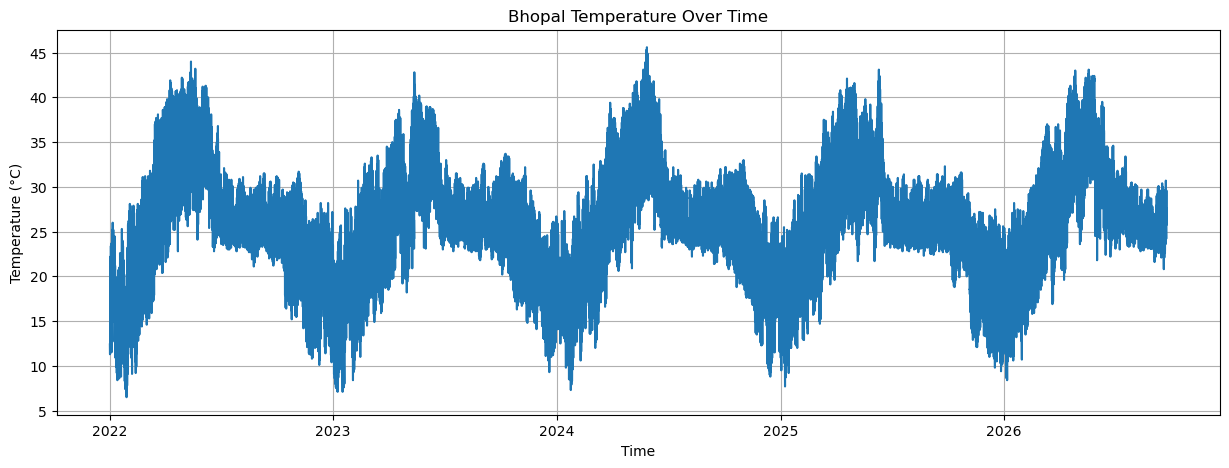

In [66]:
bhopal_df = historical_df[
    historical_df["city"] == "Bhopal"
].copy()

bhopal_df = bhopal_df.sort_values("time")

plt.figure(figsize=(15, 5))

plt.plot(
    bhopal_df["time"],
    bhopal_df["temperature_2m"]
)

plt.title("Bhopal Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.show()

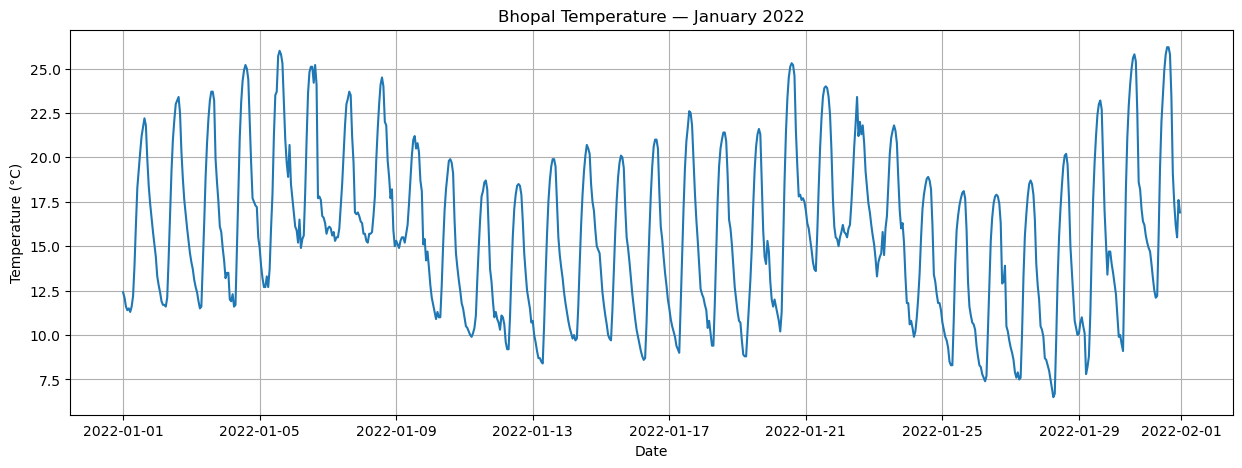

In [68]:
sample = bhopal_df[
    (bhopal_df["time"] >= "2022-01-01") &
    (bhopal_df["time"] < "2022-02-01")
]

plt.figure(figsize=(15, 5))

plt.plot(
    sample["time"],
    sample["temperature_2m"]
)

plt.title("Bhopal Temperature — January 2022")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.show()

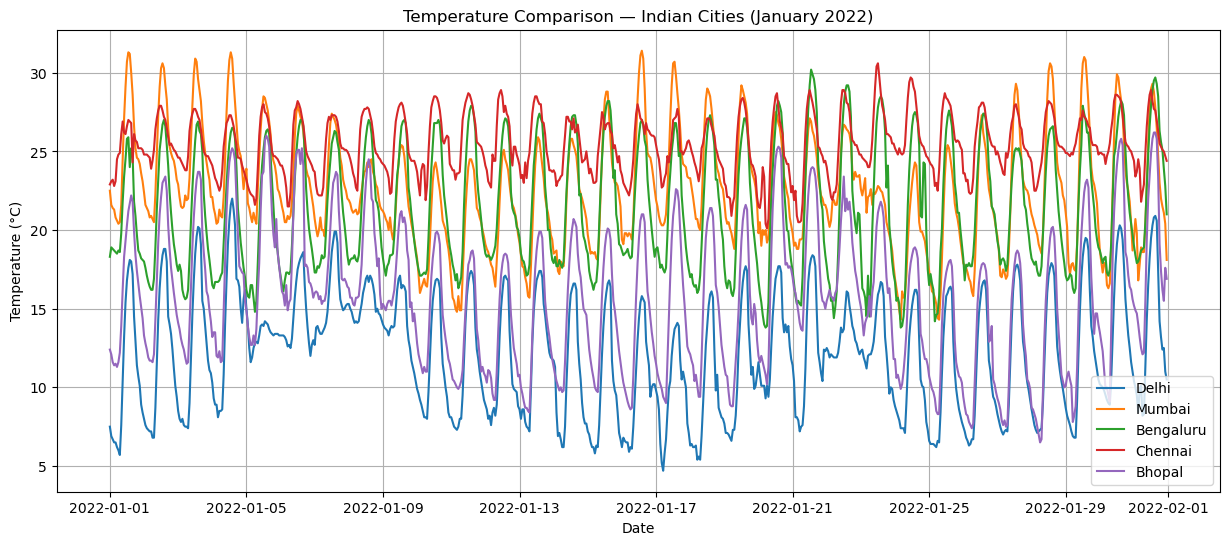

In [70]:
cities_sample = historical_df[
    (historical_df["time"] >= "2022-01-01") &
    (historical_df["time"] < "2022-02-01")
].copy()

plt.figure(figsize=(15, 6))

for city in cities:
    city_data = cities_sample[
        cities_sample["city"] == city
    ]

    plt.plot(
        city_data["time"],
        city_data["temperature_2m"],
        label=city
    )

plt.title("Temperature Comparison — Indian Cities (January 2022)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)

plt.show()

In [72]:
temperature_stats = historical_df.groupby("city")[
    "temperature_2m"
].agg([
    "min",
    "max",
    "mean",
    "std"
])

print(temperature_stats)

            min   max       mean       std
city                                      
Bengaluru  11.9  39.5  23.609839  4.232071
Bhopal      6.5  45.6  25.318592  6.434332
Chennai    18.2  41.0  28.380298  3.269575
Delhi       3.2  46.0  25.088658  8.064913
Mumbai     14.3  41.3  27.153337  3.435107


In [74]:
weather_columns = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "apparent_temperature",
    "precipitation",
    "rain",
    "surface_pressure",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "wind_gusts_10m"
]

print(historical_df[weather_columns].describe().T)

                         count        mean         std    min    25%    50%  \
temperature_2m        207240.0   25.910145    5.671059    3.2   22.8   26.3   
relative_humidity_2m  207240.0   66.761764   22.451468    4.0   52.0   71.0   
dew_point_2m          207240.0   17.995145    6.313776   -9.4   13.4   19.5   
apparent_temperature  207240.0   27.909369    6.969310    0.1   23.6   29.1   
precipitation         207240.0    0.162261    0.790012    0.0    0.0    0.0   
rain                  207240.0    0.146289    0.739302    0.0    0.0    0.0   
surface_pressure      207240.0  973.013650   36.755808  903.9  949.8  983.6   
cloud_cover           207240.0   51.317950   43.385453    0.0    2.0   50.0   
wind_speed_10m        207240.0   10.593416    5.199024    0.0    6.8    9.9   
wind_direction_10m    207240.0  192.740036  103.913720    0.0   94.0  223.0   
wind_gusts_10m        207240.0   23.381849   10.657378    0.7   15.1   22.3   

                         75%     max  
temperature_

In [76]:
correlation = historical_df[weather_columns].corr()

print(correlation.round(2))

                      temperature_2m  relative_humidity_2m  dew_point_2m  \
temperature_2m                  1.00                 -0.51          0.26   
relative_humidity_2m           -0.51                  1.00          0.66   
dew_point_2m                    0.26                  0.66          1.00   
apparent_temperature            0.93                 -0.20          0.57   
precipitation                  -0.01                  0.19          0.17   
rain                           -0.02                  0.18          0.16   
surface_pressure                0.20                  0.08          0.29   
cloud_cover                     0.04                  0.39          0.44   
wind_speed_10m                  0.20                 -0.06          0.11   
wind_direction_10m              0.13                 -0.04          0.04   
wind_gusts_10m                  0.39                 -0.21          0.12   

                      apparent_temperature  precipitation  rain  \
temperature_2m      

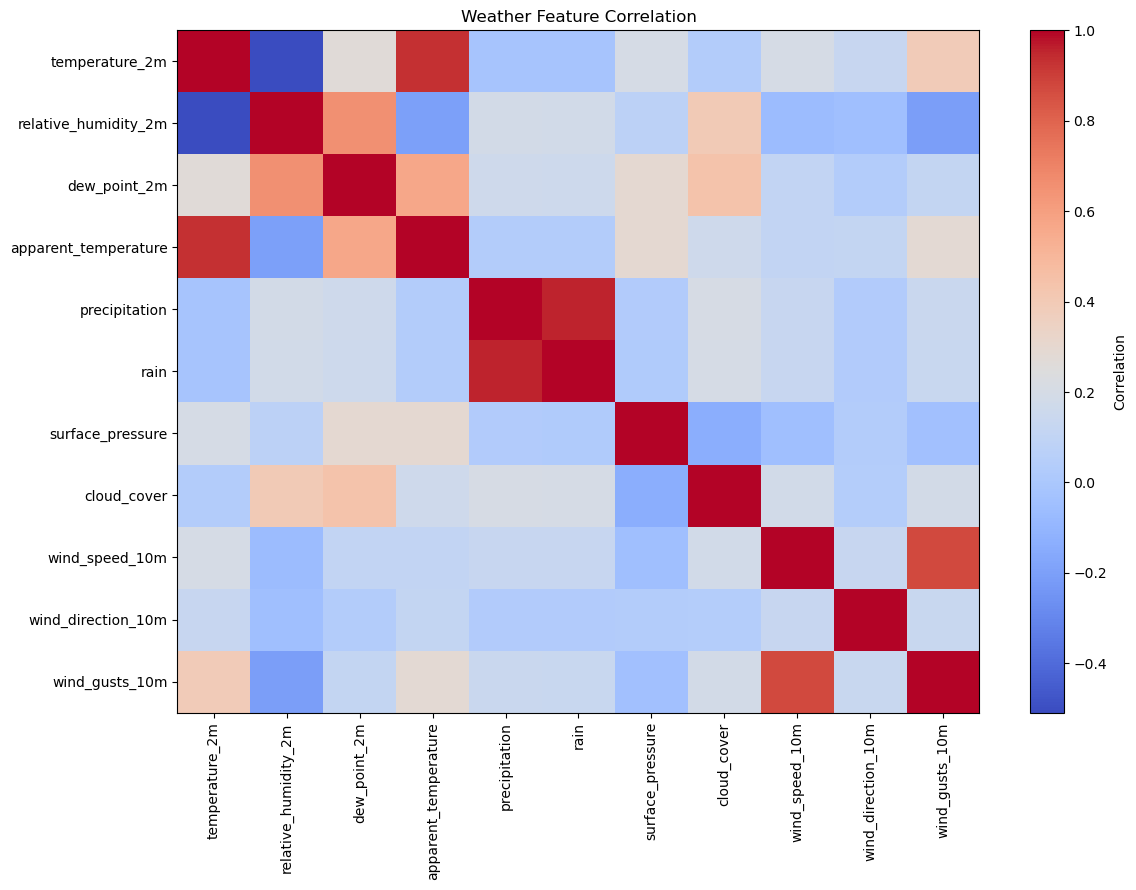

In [78]:
plt.figure(figsize=(12, 9))

plt.imshow(
    correlation,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Weather Feature Correlation")

plt.tight_layout()
plt.show()

In [82]:
historical_df.to_csv(
    "Weather_Forecasting.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [84]:
import os

print(os.path.exists("Weather_Forecasting.csv"))

True
